In [9]:
import pandas as pd
import numpy as np

In [10]:
raw_data = pd.read_csv("../data/attempt_1.csv")
raw_data.shape

(180812, 27)

In [11]:
raw_data.columns

Index(['bag', 'timestamp_ns', 'airspeed_cmd', 'airspeed_meas',
       'airspeed_error', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd',
       'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error',
       'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'battery_voltage',
       'battery_current', 'battery_percent', 'engine_fault', 'aileron_fault',
       'elevator_fault', 'rudder_fault'],
      dtype='object')

In [12]:
raw_data.head(3)

,bag,timestamp_ns,airspeed_cmd,airspeed_meas,airspeed_error,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,...,imu_x,imu_y,imu_z,battery_voltage,battery_current,battery_percent,engine_fault,aileron_fault,elevator_fault,rudder_fault
0,carbonZ_2018-07-18-12-10-11.bag,1531930511391720552,15.0,0.0,15.0,0.10,2.954323,-2.854323,-2.55,8.487809,...,-0.0748,-0.023208,-0.996428,0.0,0.01,-0.01,0,0,0,0
1,carbonZ_2018-07-18-12-10-11.bag,1531930511452938696,15.0,0.0,15.0,30.34,2.954323,27.385678,-1.31,8.487809,...,-0.0748,-0.023208,-0.996428,0.0,0.01,-0.01,0,0,0,0
2,carbonZ_2018-07-18-12-10-11.bag,1531930511484229416,15.0,0.0,15.0,30.32,2.954323,27.365677,-1.31,8.487809,...,-0.0748,-0.023208,-0.996428,0.0,0.01,-0.01,0,0,0,0


# Check Imbalance

In [13]:
raw_data[["engine_fault", "aileron_fault", "elevator_fault", "rudder_fault"]].sum()

engine_fault      18270
aileron_fault     11856
elevator_fault      453
rudder_fault       2693
dtype: int64

# Correlation with Engine Fault

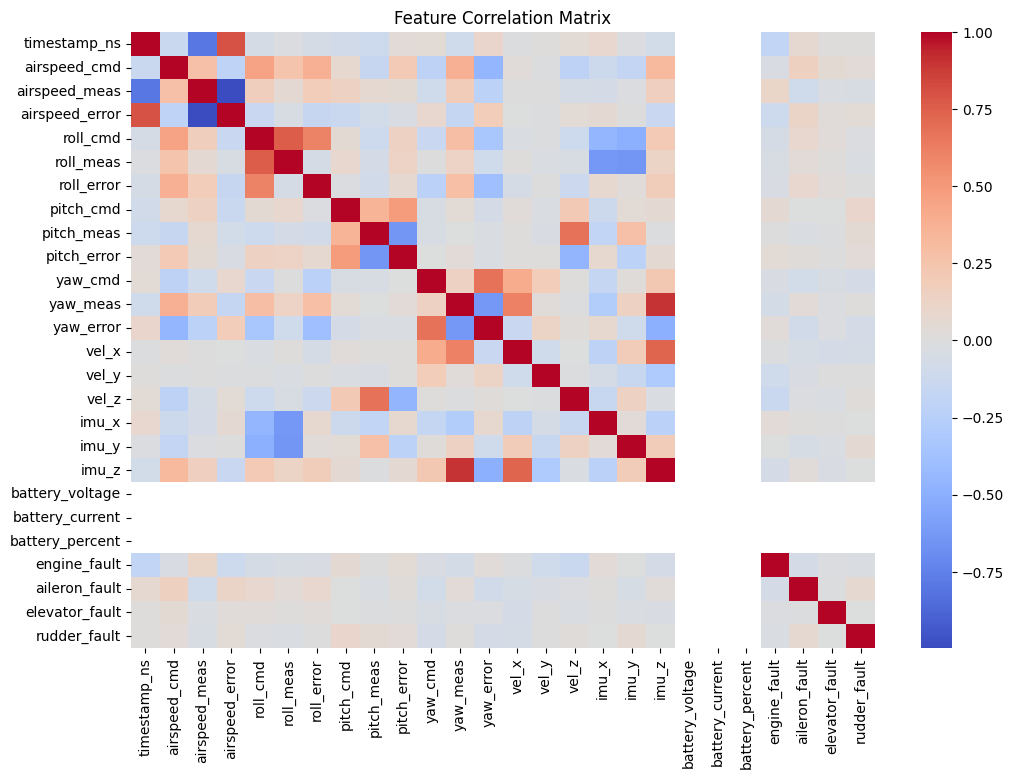

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = raw_data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
raw_data[["battery_voltage",
    "battery_current",
    "battery_percent"]].describe()

,battery_voltage,battery_current,battery_percent
count,180812.0,180812.00,180812.00
mean,0.0,0.01,-0.01
std,0.0,0.00,0.00
min,0.0,0.01,-0.01
25%,0.0,0.01,-0.01
50%,0.0,0.01,-0.01
75%,0.0,0.01,-0.01
max,0.0,0.01,-0.01


In [17]:
raw_data.nunique()

bag                    36
timestamp_ns       180812
airspeed_cmd            3
airspeed_meas       23256
airspeed_error      23256
roll_cmd             8691
roll_meas           24452
roll_error          87118
pitch_cmd            4156
pitch_meas          24452
pitch_error         88412
yaw_cmd               360
yaw_meas            24382
yaw_error           43289
vel_x               37426
vel_y               37430
vel_z               37433
imu_x               24465
imu_y               24465
imu_z               24465
battery_voltage         1
battery_current         1
battery_percent         1
engine_fault            2
aileron_fault           4
elevator_fault          2
rudder_fault            4
dtype: int64

In [19]:
print("--- Unique values per flight file ---")
print(raw_data.groupby("bag").nunique())



--- Unique values per flight file ---
                                 timestamp_ns  airspeed_cmd  airspeed_meas  \
bag                                                                          
carbonZ_2018-07-18-12-10-11.bag          4306             3              1   
carbonZ_2018-07-18-15-53-31.bag          7760             3           4145   
carbonZ_2018-07-18-16-22-01.bag          2474             3           1315   
carbonZ_2018-07-18-16-37-39.bag          4029             3           2133   
carbonZ_2018-07-30-16-28-00.bag          2894             3           1531   
carbonZ_2018-07-30-16-29-45.bag          2798             3           1500   
carbonZ_2018-07-30-16-39-00.bag         11076             3           5926   
carbonZ_2018-07-30-17-02-48.bag           977             3            525   
carbonZ_2018-07-30-17-10-45.bag          2771             3           1480   
carbonZ_2018-07-30-17-20-01.bag          2878             3           1533   
carbonZ_2018-07-30-17-36-3

In [20]:
# Print out the actual raw values of the first 10 rows of a single flight
print("\n--- Actual Raw Values Example ---")
print(raw_data.dropna().head(10))


--- Actual Raw Values Example ---
                               bag         timestamp_ns  airspeed_cmd  \
0  carbonZ_2018-07-18-12-10-11.bag  1531930511391720552          15.0   
1  carbonZ_2018-07-18-12-10-11.bag  1531930511452938696          15.0   
2  carbonZ_2018-07-18-12-10-11.bag  1531930511484229416          15.0   
3  carbonZ_2018-07-18-12-10-11.bag  1531930511543160328          15.0   
4  carbonZ_2018-07-18-12-10-11.bag  1531930511568218792          15.0   
5  carbonZ_2018-07-18-12-10-11.bag  1531930511641798152          15.0   
6  carbonZ_2018-07-18-12-10-11.bag  1531930511692711368          15.0   
7  carbonZ_2018-07-18-12-10-11.bag  1531930511734307336          15.0   
8  carbonZ_2018-07-18-12-10-11.bag  1531930511785614984          15.0   
9  carbonZ_2018-07-18-12-10-11.bag  1531930511834797992          15.0   

   airspeed_meas  airspeed_error   roll_cmd  roll_meas  roll_error  pitch_cmd  \
0            0.0            15.0   0.100000   2.954323   -2.854323  -2.550000   